# P-ML19 Phase 1a — Funding-rate features

**Hypothesis (H7).** Persistently elevated funding in a bull regime is a
leading indicator of overextension and impending drawdown. Adding
funding-rate-derived features to FEATURES_V2 should improve the *bull-fold*
IC for the late-cycle period (originally Fold 2 ATH+crash; fold mapping
shifts with the truncated 2020-01 start).

**Phase 1a scope (this notebook).** Binance perp BTCUSDT funding rate only
(no open interest — Phase 1b if Phase 1a carries signal). Three feature
candidates:
- `funding_3d_mean` — 3-day rolling mean (~9 fundings)
- `funding_zscore_30d` — daily-mean z-score over 30 days
- `funding_persistence_3d` — fraction of last 9 8h fundings same-sign

**Validation discipline** (mirrors P-ML8 / F15):
1. Data availability: funding archive starts 2020-01 → V2 dataset truncates from
   ~2,132 bars to ~1,800 bars. Re-baseline V2 on the truncated window for
   apples-to-apples comparison.
2. IC screen: |IC_total| > 0.01 AND |IC_bull| > 0.01.
3. Collinearity: max|r| ≤ 0.8 against any FEATURES_V2 column or each other.
4. Add at most 2 features at a time (learning #12).
5. Walk-forward FEATURES_V4 = V2 + selected funding features, scaled mode.
6. Per-fold IC inspection — primary success criterion is **bull-fold IC
   improvement**, especially in the late-2021 / early-2022 fold.

**Decision rule (pre-committed).**
- Late-cycle bull IC improves AND outer scaled Sharpe ≥ +1.40 → ship V4 as
  champion candidate; queue P-ML15b (per-regime tune).
- Bull IC improves but Sharpe < +1.40 → useful diagnostic; stay on V2;
  consider Phase 2 (on-chain).
- No bull IC improvement → hypothesis rejected; pivot to Phase 2 or accept
  Fold-2 as structurally unfixable at daily resolution.


In [1]:
import sys
from pathlib import Path
repo_root = Path("__file__").resolve().parent.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, scipy.stats as stats
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False, "font.size": 9})


In [2]:
# Constants — mirror P-ML13 conventions, except SINCE bumps to 2020-01 (funding-rate cap).
SYMBOL     = "BTC/USDT"
SINCE      = "2020-01-01"
UNTIL      = "2025-01-01"
HORIZON    = 1
N_SPLITS   = 5
TRAIN_FRAC = 0.6
PURGE      = 1
LONG_MA    = 200
ADX_THRESH = 25.0
MIN_BULL_BARS = 30

FEATURES_V2 = [
    "bar_ret", "bb_zscore", "rsi", "macd_hist_norm", "atr_pct",
    "bb_width", "upper_wick", "lower_wick", "hl_range",
    "vol_log_chg", "di_diff", "adx",
    "ret_5", "ret_20", "mom_zscore_20", "ret_5_minus_20",
]

FUNDING_CANDIDATES = ["funding_3d_mean", "funding_zscore_30d", "funding_persistence_3d"]

# Champion baseline positioning (hand-picked, P-ML9 / P-ML15-confirmed champion)
PRED_ZSCORE_WINDOW = 60
POSITION_SCALE     = 0.5
MAX_POSITION       = 1.0


## §1 — Build truncated V2 dataset (2020-01 onward)

In [3]:
from data.fetch import fetch_ohlcv
from data.funding import fetch_funding_rate
from ml.features import build_feature_matrix
from ml.features.momentum import build_momentum_features
from ml.features.funding import build_funding_features
from ml.labels import forward_return
from ml.regime import RegimeClassifier
from ml.validation import purged_wf_splits
from ml.models import RegimeEnsemble
from backtesting import compute_metrics

# OHLCV (truncated to 2020-01 onward).
df_raw = fetch_ohlcv(symbol=SYMBOL, timeframe="1d", since=SINCE, until=UNTIL)

feats_base = build_feature_matrix(df_raw)
feats_mom  = build_momentum_features(df_raw)
label      = forward_return(df_raw, horizon=HORIZON)
rc         = RegimeClassifier(long_ma=LONG_MA, adx_thresh=ADX_THRESH)
reg        = rc.transform(df_raw)

for s in [feats_base, feats_mom, label, reg]:
    if hasattr(s.index, "tz") and s.index.tz is not None:
        s.index = s.index.tz_localize(None)

# Funding-rate features.
funding_8h = fetch_funding_rate(symbol="BTCUSDT", since=SINCE, until=UNTIL)
feats_funding = build_funding_features(funding_8h)
if feats_funding.index.tz is not None:
    feats_funding.index = feats_funding.index.tz_localize(None)

# Combine.
comb_v2 = pd.concat([feats_base, feats_mom, label, reg["regime"]], axis=1).dropna()
comb_v4 = pd.concat([feats_base, feats_mom, feats_funding, label, reg["regime"]], axis=1).dropna()

# bar-over-bar log returns aligned with the comb index for equity simulation.
df_raw_naive = df_raw.copy()
df_raw_naive.index = df_raw_naive.index.normalize()
if df_raw_naive.index.tz is not None:
    df_raw_naive.index = df_raw_naive.index.tz_localize(None)
df_raw_naive = df_raw_naive[~df_raw_naive.index.duplicated(keep="last")]

def _bar_ret(idx):
    s = df_raw_naive["close"].reindex(idx)
    return np.log(s / s.shift(1)).fillna(0)

bar_ret_v2 = _bar_ret(comb_v2.index)
bar_ret_v4 = _bar_ret(comb_v4.index)

print(f"V2 truncated: {len(comb_v2):,} bars | {comb_v2.index[0].date()} -> {comb_v2.index[-1].date()}")
print(f"V4 (V2+fund): {len(comb_v4):,} bars | {comb_v4.index[0].date()} -> {comb_v4.index[-1].date()}")
print(f"Funding bars dropped vs V2: {len(comb_v2) - len(comb_v4)} (warmup of funding rolling windows)")
print(f"Bull bars (V4): {(comb_v4['regime']=='bull').sum():,} ({(comb_v4['regime']=='bull').mean()*100:.1f}%)")


V2 truncated: 1,767 bars | 2020-03-01 -> 2024-12-31
V4 (V2+fund): 1,767 bars | 2020-03-01 -> 2024-12-31
Funding bars dropped vs V2: 0 (warmup of funding rolling windows)
Bull bars (V4): 616 (34.9%)


## §2 — IC screen for funding-feature candidates

In [4]:
# Compute Spearman IC of each candidate vs the next-bar forward return.
# Compute total IC, bull-only IC, and bear-only IC for each candidate.
y_v4 = comb_v4[label.name]
regime_v4 = comb_v4["regime"]

def _ic(x, y):
    valid = ~(x.isna() | y.isna())
    if valid.sum() < 30:
        return np.nan, np.nan
    rho, p = stats.spearmanr(x[valid], y[valid])
    return rho, p

print(f"{'Feature':<24} {'IC_total':>10} {'p':>7}   {'IC_bull':>10} {'p':>7}   {'IC_bear':>10} {'p':>7}   pass?")
print("-" * 96)

ic_results = {}
for f in FUNDING_CANDIDATES:
    x = comb_v4[f]
    ic_t, p_t = _ic(x, y_v4)
    bull = regime_v4 == "bull"
    bear = regime_v4 == "bear"
    ic_b, p_b = _ic(x[bull], y_v4[bull])
    ic_be, p_be = _ic(x[bear], y_v4[bear])
    pass_screen = (abs(ic_t) > 0.01) and (abs(ic_b) > 0.01)
    ic_results[f] = {"ic_total": ic_t, "ic_bull": ic_b, "ic_bear": ic_be,
                      "pass": pass_screen}
    print(f"  {f:<22} {ic_t:>+10.4f} {p_t:>7.3f}   {ic_b:>+10.4f} {p_b:>7.3f}   "
          f"{ic_be:>+10.4f} {p_be:>7.3f}   {'YES' if pass_screen else 'no'}")

passed = [f for f, r in ic_results.items() if r["pass"]]
print(f"\nPassed: {len(passed)} / {len(FUNDING_CANDIDATES)} -> {passed}")


Feature                    IC_total       p      IC_bull       p      IC_bear       p   pass?
------------------------------------------------------------------------------------------------
  funding_3d_mean           -0.0132   0.579      -0.0072   0.859      -0.0338   0.511   no
  funding_zscore_30d        -0.0342   0.151      +0.0360   0.372      -0.0683   0.184   YES
  funding_persistence_3d    -0.0084   0.723      +0.0080   0.844      +0.0155   0.763   no

Passed: 1 / 3 -> ['funding_zscore_30d']


## §3 — Collinearity check vs FEATURES_V2

In [5]:
print("Max |Spearman r| between each candidate and any FEATURES_V2 column:")
print(f"{'Feature':<24} {'max|r|':>8}  {'against':<22}  {'pass <=0.8?':<12}")
print("-" * 80)

for f in FUNDING_CANDIDATES:
    x = comb_v4[f]
    rs = []
    for v2 in FEATURES_V2:
        valid = ~(x.isna() | comb_v4[v2].isna())
        if valid.sum() < 30:
            continue
        rho, _ = stats.spearmanr(x[valid], comb_v4[v2][valid])
        rs.append((v2, abs(rho)))
    rs.sort(key=lambda t: -t[1])
    top_v2, top_r = rs[0]
    print(f"  {f:<22} {top_r:>8.3f}  {top_v2:<22}  {'YES' if top_r <= 0.8 else 'no'}")

# And among funding candidates themselves
print("\nPairwise |r| among funding candidates:")
for i, f1 in enumerate(FUNDING_CANDIDATES):
    for f2 in FUNDING_CANDIDATES[i+1:]:
        x1, x2 = comb_v4[f1], comb_v4[f2]
        valid = ~(x1.isna() | x2.isna())
        rho, _ = stats.spearmanr(x1[valid], x2[valid])
        print(f"  {f1:<24} ~ {f2:<24}  r = {rho:+.3f}")


Max |Spearman r| between each candidate and any FEATURES_V2 column:
Feature                    max|r|  against                 pass <=0.8? 
--------------------------------------------------------------------------------
  funding_3d_mean           0.435  rsi                     YES
  funding_zscore_30d        0.439  macd_hist_norm          YES
  funding_persistence_3d    0.316  rsi                     YES

Pairwise |r| among funding candidates:
  funding_3d_mean          ~ funding_zscore_30d        r = +0.337
  funding_3d_mean          ~ funding_persistence_3d    r = +0.795
  funding_zscore_30d       ~ funding_persistence_3d    r = +0.317


## §4 — Select features (≤2 per learning #12)

Apply selection rule:
- Must pass IC screen (|IC_total| > 0.01 and |IC_bull| > 0.01)
- Must pass collinearity check (max|r| ≤ 0.8 with V2 features and each other)
- Pick top 2 by |IC_bull|, since the hypothesis targets bull-fold improvement


In [6]:
# Rank by |IC_bull| among passing features
ranked = sorted(
    [f for f in FUNDING_CANDIDATES if ic_results[f]["pass"]],
    key=lambda f: -abs(ic_results[f]["ic_bull"])
)

# Drop pairs with |r|>0.8 (keep the higher-IC one)
selected = []
for f in ranked:
    keep = True
    for s in selected:
        x1, x2 = comb_v4[f], comb_v4[s]
        valid = ~(x1.isna() | x2.isna())
        rho, _ = stats.spearmanr(x1[valid], x2[valid])
        if abs(rho) > 0.8:
            keep = False
            break
    if keep:
        selected.append(f)
    if len(selected) >= 2:
        break

print(f"Selected features for FEATURES_V4: {selected}")
FEATURES_V4 = FEATURES_V2 + selected
print(f"FEATURES_V4 ({len(FEATURES_V4)} features): {FEATURES_V4}")


Selected features for FEATURES_V4: ['funding_zscore_30d']
FEATURES_V4 (17 features): ['bar_ret', 'bb_zscore', 'rsi', 'macd_hist_norm', 'atr_pct', 'bb_width', 'upper_wick', 'lower_wick', 'hl_range', 'vol_log_chg', 'di_diff', 'adx', 'ret_5', 'ret_20', 'mom_zscore_20', 'ret_5_minus_20', 'funding_zscore_30d']


## §5 — Walk-forward: V2 (truncated baseline) vs V4

Re-baseline V2 on the truncated 2020-01-onward window so the comparison is
apples-to-apples. Then run V4 with the selected funding features.


In [7]:
def run_walk_forward(X, y, regime, splits):
    folds = []
    for i, (tr, te) in enumerate(splits):
        ens = RegimeEnsemble(min_bull_bars=MIN_BULL_BARS)
        ens.fit(X.iloc[tr], y.iloc[tr], regime.iloc[tr])
        preds = ens.predict(X.iloc[te], regime.iloc[te])
        actual = y.iloc[te].values
        ic, _ = stats.spearmanr(preds, actual)
        bull_te = (regime.iloc[te] == "bull").values
        ic_bull = (stats.spearmanr(preds[bull_te], actual[bull_te])[0]
                    if bull_te.sum() > 10 else np.nan)
        folds.append({"fold": i+1, "te": te, "IC": ic, "bull_IC": ic_bull, "preds": preds})
    return folds


def build_equity(folds, bar_ret, idx, mode, pz_win, pos_scale, max_pos):
    pieces, anchor = [], 1.0
    for r in folds:
        te, preds = r["te"], r["preds"]
        if mode == "binary":
            pos = np.sign(preds)
        else:
            pred_s = pd.Series(preds, index=idx[te])
            rm = pred_s.rolling(pz_win, min_periods=1).mean()
            rs = pred_s.rolling(pz_win, min_periods=1).std().replace(0, np.nan)
            pz = (pred_s - rm) / rs
            pos = (pz * pos_scale).clip(-max_pos, max_pos).fillna(0).values

        ret    = bar_ret.iloc[te].values
        pos_sh = np.roll(pos, 1); pos_sh[0] = 0
        eq     = np.cumprod(1 + pos_sh * ret); eq[0] = 1.0
        s      = pd.Series(eq, index=idx[te])
        s      = s / s.iloc[0] * anchor
        anchor = float(s.iloc[-1])
        pieces.append(s)
    return pd.concat(pieces)


# (a) V2 baseline on truncated window
X_v2 = comb_v2[FEATURES_V2]
y_v2 = comb_v2[label.name]
reg_v2 = comb_v2["regime"].fillna("ranging")
splits_v2 = list(purged_wf_splits(len(comb_v2), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

v2_folds = run_walk_forward(X_v2, y_v2, reg_v2, splits_v2)
v2_eq_sc = build_equity(v2_folds, bar_ret_v2, comb_v2.index, "scaled",
                         PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION)
v2_eq_bin = build_equity(v2_folds, bar_ret_v2, comb_v2.index, "binary",
                          PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION)
m_v2_sc  = compute_metrics(v2_eq_sc)
m_v2_bin = compute_metrics(v2_eq_bin)
v2_mean_ic = float(np.mean([f["IC"] for f in v2_folds]))
v2_icir    = v2_mean_ic / float(np.std([f["IC"] for f in v2_folds]))

# (b) V4 on the same window (~slightly fewer bars due to funding warmup)
X_v4 = comb_v4[FEATURES_V4]
y_v4 = comb_v4[label.name]
reg_v4_s = comb_v4["regime"].fillna("ranging")
splits_v4 = list(purged_wf_splits(len(comb_v4), N_SPLITS, TRAIN_FRAC, purge_bars=PURGE))

v4_folds = run_walk_forward(X_v4, y_v4, reg_v4_s, splits_v4)
v4_eq_sc = build_equity(v4_folds, bar_ret_v4, comb_v4.index, "scaled",
                         PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION)
v4_eq_bin = build_equity(v4_folds, bar_ret_v4, comb_v4.index, "binary",
                          PRED_ZSCORE_WINDOW, POSITION_SCALE, MAX_POSITION)
m_v4_sc  = compute_metrics(v4_eq_sc)
m_v4_bin = compute_metrics(v4_eq_bin)
v4_mean_ic = float(np.mean([f["IC"] for f in v4_folds]))
v4_icir    = v4_mean_ic / float(np.std([f["IC"] for f in v4_folds]))

# B&H benchmark
bah_close = df_raw_naive["close"].reindex(comb_v2.index)
bah_eq    = bah_close / bah_close.iloc[0]
m_bah     = compute_metrics(bah_eq)


## §6 — Results & decision rule

In [8]:
print("="*92)
print("P-ML19 Phase 1a — RESULTS  (truncated dataset 2020-01 -> 2024-12)")
print("="*92)
print(f"\n{'Config':<44} {'Sharpe':>9} {'Return':>11} {'MaxDD':>9} {'Mean IC':>9} {'ICIR':>7}")
print("-"*92)
print(f"  {'V2 truncated scaled (re-baseline)':<44} {m_v2_sc['sharpe_ratio']:>+9.3f} "
      f"{m_v2_sc['total_return']*100:>+10.1f}% {m_v2_sc['max_drawdown']*100:>+8.1f}% "
      f"{v2_mean_ic:>+9.4f} {v2_icir:>+7.3f}")
print(f"  {'V4 (V2 + funding) scaled':<44} {m_v4_sc['sharpe_ratio']:>+9.3f} "
      f"{m_v4_sc['total_return']*100:>+10.1f}% {m_v4_sc['max_drawdown']*100:>+8.1f}% "
      f"{v4_mean_ic:>+9.4f} {v4_icir:>+7.3f}")
print(f"  {'V2 truncated binary':<44} {m_v2_bin['sharpe_ratio']:>+9.3f} "
      f"{m_v2_bin['total_return']*100:>+10.1f}% {m_v2_bin['max_drawdown']*100:>+8.1f}%")
print(f"  {'V4 binary':<44} {m_v4_bin['sharpe_ratio']:>+9.3f} "
      f"{m_v4_bin['total_return']*100:>+10.1f}% {m_v4_bin['max_drawdown']*100:>+8.1f}%")
print(f"  {'B&H (truncated)':<44} {m_bah['sharpe_ratio']:>+9.3f} "
      f"{m_bah['total_return']*100:>+10.1f}% {m_bah['max_drawdown']*100:>+8.1f}%")

# Lift on scaled mode (the champion definition)
lift_sharpe = m_v4_sc["sharpe_ratio"] - m_v2_sc["sharpe_ratio"]
lift_maxdd  = m_v4_sc["max_drawdown"] - m_v2_sc["max_drawdown"]
print(f"\nLift V4 vs V2 (scaled): ΔSharpe = {lift_sharpe:+.3f}, ΔMaxDD = {lift_maxdd*100:+.1f}pp")


P-ML19 Phase 1a — RESULTS  (truncated dataset 2020-01 -> 2024-12)

Config                                          Sharpe      Return     MaxDD   Mean IC    ICIR
--------------------------------------------------------------------------------------------
  V2 truncated scaled (re-baseline)               +0.594      +74.5%    -42.8%   +0.0384  +0.647
  V4 (V2 + funding) scaled                        +0.775     +123.1%    -42.2%   +0.0401  +0.813
  V2 truncated binary                             +0.491      +56.6%    -73.2%
  V4 binary                                       +0.090      -42.8%    -71.4%
  B&H (truncated)                                 +1.092     +997.0%    -76.6%

Lift V4 vs V2 (scaled): ΔSharpe = +0.181, ΔMaxDD = +0.7pp


## §7 — Per-fold IC (V2 vs V4): which fold benefits?

In [9]:
# Per-fold IC comparison.
# For V4 vs V2 to be apples-to-apples, the fold boundaries differ slightly because V4
# has a few fewer bars (funding warmup). Report each separately.
print("V2 truncated, per fold:")
print(f"  {'Fold':<5} {'Period':<28} {'IC':>9} {'Bull IC':>9}")
for f in v2_folds:
    te = f["te"]
    period = f"{comb_v2.index[te[0]].date()} -> {comb_v2.index[te[-1]].date()}"
    bull = f"{f['bull_IC']:+.4f}" if not np.isnan(f["bull_IC"]) else "n/a"
    print(f"  {f['fold']:<3}   {period:<28} {f['IC']:>+9.4f}   {bull:>9}")

print("\nV4 (V2 + funding), per fold:")
print(f"  {'Fold':<5} {'Period':<28} {'IC':>9} {'Bull IC':>9}")
for f in v4_folds:
    te = f["te"]
    period = f"{comb_v4.index[te[0]].date()} -> {comb_v4.index[te[-1]].date()}"
    bull = f"{f['bull_IC']:+.4f}" if not np.isnan(f["bull_IC"]) else "n/a"
    print(f"  {f['fold']:<3}   {period:<28} {f['IC']:>+9.4f}   {bull:>9}")

# Identify the late-2021 / early-2022 fold (the "ATH+crash" target)
print("\nLate-2021 / early-2022 fold inspection (the H7 target):")
def find_fold(folds, idx, target_year, target_month):
    for f in folds:
        te = f["te"]
        d_start = idx[te[0]]
        d_end = idx[te[-1]]
        if (d_start.year, d_start.month) <= (target_year, target_month) <= (d_end.year, d_end.month):
            return f
    return None

# 2021-11 was the BTC cycle top. Look for the fold containing it.
v2_target = find_fold(v2_folds, comb_v2.index, 2021, 11)
v4_target = find_fold(v4_folds, comb_v4.index, 2021, 11)
if v2_target and v4_target:
    delta_total = v4_target["IC"] - v2_target["IC"]
    delta_bull = ((v4_target["bull_IC"] - v2_target["bull_IC"])
                   if not (np.isnan(v4_target["bull_IC"]) or np.isnan(v2_target["bull_IC"]))
                   else None)
    print(f"  V2 target fold {v2_target['fold']}: total IC {v2_target['IC']:+.4f}, "
          f"bull IC {v2_target['bull_IC']:+.4f}")
    print(f"  V4 target fold {v4_target['fold']}: total IC {v4_target['IC']:+.4f}, "
          f"bull IC {v4_target['bull_IC']:+.4f}")
    print(f"  Δtotal: {delta_total:+.4f}   "
          f"Δbull: {('%+.4f' % delta_bull) if delta_bull is not None else 'n/a'}")
else:
    print("  could not locate fold containing 2021-11; inspect manually")


V2 truncated, per fold:
  Fold  Period                              IC   Bull IC
  1     2020-12-20 -> 2021-10-09       -0.0199     -0.0536
  2     2021-10-10 -> 2022-07-30       +0.1274     +0.1065
  3     2022-07-31 -> 2023-05-20       +0.0814     +0.0837
  4     2023-05-21 -> 2024-03-09       +0.0311     +0.0270
  5     2024-03-10 -> 2024-12-28       -0.0279     +0.1271

V4 (V2 + funding), per fold:
  Fold  Period                              IC   Bull IC
  1     2020-12-20 -> 2021-10-09       -0.0123     -0.0481
  2     2021-10-10 -> 2022-07-30       +0.1039     -0.0106
  3     2022-07-31 -> 2023-05-20       +0.0838     +0.1286
  4     2023-05-21 -> 2024-03-09       +0.0429     -0.0018
  5     2024-03-10 -> 2024-12-28       -0.0181     +0.1323

Late-2021 / early-2022 fold inspection (the H7 target):
  V2 target fold 2: total IC +0.1274, bull IC +0.1065
  V4 target fold 2: total IC +0.1039, bull IC -0.0106
  Δtotal: -0.0235   Δbull: -0.1170


## §8 — Decision rule verdict

In [10]:
bull_ic_target_v2 = v2_target["bull_IC"] if v2_target else np.nan
bull_ic_target_v4 = v4_target["bull_IC"] if v4_target else np.nan
bull_improved = (not np.isnan(bull_ic_target_v4) and not np.isnan(bull_ic_target_v2)
                  and bull_ic_target_v4 > bull_ic_target_v2)
sharpe_threshold = m_v4_sc["sharpe_ratio"] >= 1.40

print("="*92)
print("DECISION (pre-committed in roadmap)")
print("="*92)
print(f"  Late-cycle bull IC improved?  {'YES' if bull_improved else 'NO'} "
      f"(V2 {bull_ic_target_v2:+.4f} -> V4 {bull_ic_target_v4:+.4f})")
print(f"  V4 outer scaled Sharpe ≥ 1.40?  {'YES' if sharpe_threshold else 'NO'}  "
      f"(actual {m_v4_sc['sharpe_ratio']:+.3f})")
print()

if bull_improved and sharpe_threshold:
    print("  → SHIP V4. Promote FEATURES_V4 as new champion candidate.")
    print("    Next: queue P-ML15b (per-regime hyperparam tune on V4).")
elif bull_improved:
    print("  → DIAGNOSTIC ONLY. Bull IC improvement real but doesn't translate to")
    print("    portfolio Sharpe. Stay on V2 champion. Consider Phase 2 (on-chain).")
else:
    print("  → HYPOTHESIS REJECTED. No bull-IC improvement.")
    print("    Pivot to Phase 2 on-chain or accept Fold-2 as structurally unfixable.")


DECISION (pre-committed in roadmap)
  Late-cycle bull IC improved?  NO (V2 +0.1065 -> V4 -0.0106)
  V4 outer scaled Sharpe ≥ 1.40?  NO  (actual +0.775)

  → HYPOTHESIS REJECTED. No bull-IC improvement.
    Pivot to Phase 2 on-chain or accept Fold-2 as structurally unfixable.


## §9 — Equity overlay

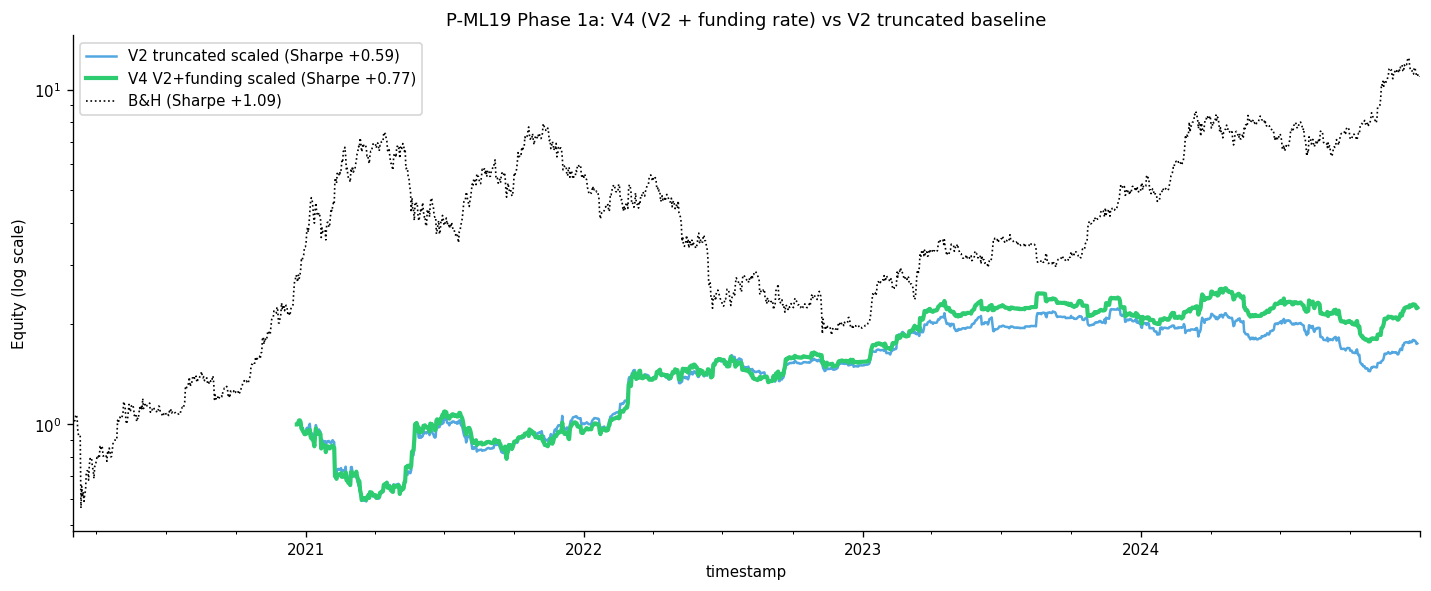

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

v2_eq_sc.plot(ax=ax, label=f"V2 truncated scaled (Sharpe {m_v2_sc['sharpe_ratio']:+.2f})",
              color="#3498db", linewidth=1.5, alpha=0.85)
v4_eq_sc.plot(ax=ax, label=f"V4 V2+funding scaled (Sharpe {m_v4_sc['sharpe_ratio']:+.2f})",
              color="#2ecc71", linewidth=2.5)
bah_eq.plot(ax=ax, label=f"B&H (Sharpe {m_bah['sharpe_ratio']:+.2f})",
            color="black", linestyle=":", linewidth=1.0)

ax.set_yscale("log")
ax.set_ylabel("Equity (log scale)")
ax.set_title("P-ML19 Phase 1a: V4 (V2 + funding rate) vs V2 truncated baseline")
ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()


## §10 — F24 findings template

After running, log F24 in `findings.md` with the decision-rule verdict, and
update `roadmap.md`. Suggested skeleton:

```markdown
## F24 — Funding-rate features (P-ML19 Phase 1a)
**Date:** 2026-05-08 | **Notebook:** `p_ml19_funding_features.ipynb`

Binance perp BTCUSDT funding rate from data.binance.vision archive
(2020-01 onward). Three candidates IC-screened; ___ selected for V4.
Walk-forward on truncated 2020-01 → 2024-12 dataset (~1,800 bars).

**Result:** V4 scaled Sharpe ___ vs V2 truncated baseline ___ (Δ ___).
Late-cycle (2021-11) bull IC: V2 ___ → V4 ___.

**Verdict:** [ship V4 / diagnostic only / rejected].
**Next:** [Phase 1b OI / Phase 2 on-chain / per-regime tune / pivot].
```
